In [ ]:
import numpy as np
import pandas as pd

Feature Engineering Technicals

In [ ]:
df_master_reliance = pd.read_csv(r"features/reliance.csv", index_col=0)

In [ ]:
from arch import arch_model # Required for your GARCH note

def feature_engineering_technicals(df):
    feat = df.copy()
    
    # ==========================================
    # 1. STATIONARITY & RETURNS (Log Returns)
    # ==========================================
    feat['Log_Return_1D'] = np.log(feat['Close'] / feat['Close'].shift(1))
    feat['Log_Return_5D'] = feat['Log_Return_1D'].rolling(window=5, min_periods=1).sum()
    feat['Log_Return_20D'] = feat['Log_Return_1D'].rolling(window=20, min_periods=1).sum()
    feat['Log_Return_60D'] = feat['Log_Return_1D'].rolling(window=60, min_periods=1).sum()
    # ==========================================
    # 2. RISK METRICS (From your notes)
    # ==========================================
    # A. Drawdown (Rolling 252-Day High Water Mark)
    rolling_max = feat['Close'].rolling(window=252, min_periods=1).max()
    feat['Drawdown'] = (feat['Close'] / rolling_max) - 1
    
    # B. GARCH(1,1) Volatility Extraction
    # # We fit a GARCH model to the historical log returns to extract 'Conditional Variance'
    # # (Wrapped in a try-except because GARCH requires a decent amount of data to converge)
    # try:
    #     # Scale up returns for optimizer stability
    #     returns_scaled = feat['Log_Return_1D'].dropna() * 100 
    #     am = arch_model(returns_scaled, vol='Garch', p=1, q=1, rescale=False)
    #     res = am.fit(disp='off')
    #     # Scale back down and align index
    #     feat['GARCH_Volatility'] = (res.conditional_volatility / 100).reindex(feat.index)
    # except:
    #     print("⚠️ GARCH model failed to converge. Defaulting to Rolling StdDev.")
    #     feat['GARCH_Volatility'] = feat['Log_Return_1D'].rolling(20, min_periods=1).std()

    # B. Historical Volatility (20-Day Rolling Standard Deviation)
    feat['Volatility_20D'] = feat['Log_Return_1D'].rolling(window=20, min_periods=1).std()
    # ==========================================
    # 3. TECHNICAL INDICATORS (4a - 4f)
    # ==========================================
    
    # 4a. Moving Averages (Distance from SMA/EMA to stay stationary)
    feat['SMA_20'] = feat['Close'].rolling(window=20, min_periods=1).mean()
    feat['EMA_20'] = feat['Close'].ewm(span=20, adjust=False).mean()
    feat['Dist_SMA_20'] = (feat['Close'] / feat['SMA_20']) - 1
    feat['Dist_EMA_20'] = (feat['Close'] / feat['EMA_20']) - 1

    # 4b. RSI (14-Day)
    delta = feat['Close'].diff()
    gain = delta.where(delta > 0, 0).ewm(com=13, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0)).ewm(com=13, adjust=False).mean()
    rs = gain / loss
    feat['RSI_14'] = 100 - (100 / (1 + rs))

    # 4c. MACD (12, 26, 9)
    ema_12 = feat['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = feat['Close'].ewm(span=26, adjust=False).mean()
    macd_line = ema_12 - ema_26
    macd_signal = macd_line.ewm(span=9, adjust=False).mean()
    feat['MACD_Histogram'] = (macd_line - macd_signal) / feat['Close'] # Normalized

    # 4d. Bollinger Bands
    rolling_std = feat['Close'].rolling(window=20,min_periods=1).std()
    upper_band = feat['SMA_20'] + (rolling_std * 2)
    lower_band = feat['SMA_20'] - (rolling_std * 2)
    feat['BB_Bandwidth'] = (upper_band - lower_band) / feat['SMA_20']
    feat['BB_PctB'] = (feat['Close'] - lower_band) / (upper_band - lower_band)

    # 4e. Buying & Selling Pressure
    range_hl = (feat['High'] - feat['Low']).replace(0, np.nan)
    feat['Buying_Pressure'] = (feat['Close'] - feat['Low']) / range_hl
    feat['Selling_Pressure'] = (feat['High'] - feat['Close']) / range_hl

    # 4f. Lagged Features (Momentum & Mean Reversion)
    feat['Return_Lag1'] = feat['Log_Return_1D'].shift(1)
    feat['Return_Lag2'] = feat['Log_Return_1D'].shift(2)
    
    # Lagged Volume Attention
    vol_sma_20 = feat['Volume'].rolling(20, min_periods=1).mean()
    feat['Volume_Attention_Today'] = (feat['Volume'] / vol_sma_20)
    feat['Volume_Attention_Lag1'] = feat['Volume_Attention_Today'].shift(1)

    # ==========================================
    # CLEANUP & STATIONARITY ENFORCEMENT
    # ==========================================
    # Drop all raw prices. Machine learning models should ONLY see the engineered ratios. ALWAYS USE RELATIVE FEATURES.
    drop_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'EMA_20']
    feat.drop(columns=[c for c in drop_cols if c in feat.columns], inplace=True)
    
    feat.dropna(inplace=True)
    return feat



In [8]:
df_technical = feature_engineering_technicals(df_master_reliance)

In [9]:
df_technical

,Total Income From Operations,Net P/L After M.I & Associates,Basic EPS,EPS_TTM,Annualized_Sales,Annualized_Profit,Equity Share Capital,Reserves,Borrowings,Total,...,RSI_14,MACD_Histogram,BB_Bandwidth,BB_PctB,Buying_Pressure,Selling_Pressure,Return_Lag1,Return_Lag2,Volume_Attention_Today,Volume_Attention_Lag1
2020-01-06,153179,11640,18.36,71.49,598271,43368,5926,381186,307714,997630,...,40.111801,0.000621,0.047425,0.231209,0.117058,0.882942,0.001204,0.016881,1.270117,1.194587
2020-01-07,153179,11640,18.36,71.49,598271,43368,5926,381186,307714,997630,...,57.762942,0.000813,0.041283,0.547280,0.528574,0.471426,-0.023465,0.001204,0.888350,1.270117
2020-01-08,153179,11640,18.36,71.49,598271,43368,5926,381186,307714,997630,...,49.910472,0.000411,0.038065,0.377879,0.128834,0.871166,0.015267,-0.023465,0.875737,0.888350
2020-01-09,153179,11640,18.36,71.49,598271,43368,5926,381186,307714,997630,...,65.350085,0.001557,0.044279,0.852858,0.893336,0.106664,-0.007539,0.015267,0.839484,0.875737
2020-01-10,153179,11640,18.36,71.49,598271,43368,5926,381186,307714,997630,...,65.132971,0.002171,0.046328,0.790202,0.437160,0.562840,0.022770,-0.007539,0.726482,0.839484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,254623,18165,13.42,61.41,999629,83106,13532,829668,374313,1949713,...,64.197999,-0.000288,0.035871,0.838168,0.203122,0.796878,0.006560,0.013314,0.812828,1.059656
2025-12-24,254623,18165,13.42,61.41,999629,83106,13532,829668,374313,1949713,...,57.720001,-0.000647,0.034433,0.629363,0.208144,0.791856,-0.002988,0.006560,0.982453,0.812828
2025-12-26,254623,18165,13.42,61.41,999629,83106,13532,829668,374313,1949713,...,58.084394,-0.000881,0.034003,0.653959,0.731334,0.268666,-0.007990,-0.002988,0.268809,0.982453
2025-12-29,254623,18165,13.42,61.41,999629,83106,13532,829668,374313,1949713,...,51.574252,-0.001637,0.032641,0.413328,0.137931,0.862069,0.000642,-0.007990,0.706786,0.268809


In [10]:
import numpy as np
import pandas as pd

def engineer_exhaustive_macro(df):
    m = df.copy()
    global_cols = ['Crude_Oil', 'Gold_Price', 'USDINR', 'SP500', 'Global_Bond_Yield']
    domestic_cols = ['Nifty50', 'India_VIX', 'India_10Y_Yield', 'Repo_Rate', 'CPI']
    m['Yield Gap'] = m['Earnings_Yield'] - m['India_10Y_Yield']

    # ---------------------------------------------------------
    # STEP 2: RETURNS & MOMENTUM (Log Space)
    # ---------------------------------------------------------
    for col in ['Crude_Oil', 'Gold_Price', 'USDINR', 'SP500', 'Nifty50']:
        m[f'{col}_Ret_1D'] = np.log(m[col] / m[col].shift(1))
        m[f'{col}_Ret_5D'] = m[f'{col}_Ret_1D'].rolling(window=5, min_periods=1).sum()

    # ---------------------------------------------------------
    # STEP 3: INTER-MARKET RATIOS & SPREADS
    # ---------------------------------------------------------
    # Gold-to-Oil Ratio (Safe Haven vs Growth)
    m['Gold_Oil_Ratio'] = m['Gold_Price'] / m['Crude_Oil']
    
    # Global vs Domestic Equity Momentum
    m['Global_Equity_Diff'] = m['SP500_Ret_1D'] - m['Nifty50_Ret_1D']
    
    # Domestic Yield Spread (Yield Curve Slope)
    m['Domestic_Yield_Slope'] = m['India_10Y_Yield'] - m['Repo_Rate']
    
    # Global Yield Spread (Capital Flow Driver)
    m['Global_Yield_Spread'] = m['India_10Y_Yield'] - m['Global_Bond_Yield']
    
    # Real Interest Rate (Inflation Adjusted)
    m['Real_Rate'] = m['India_10Y_Yield'] - m['CPI']
    
    # ---------------------------------------------------------
    # STEP 4: VOLATILITY & FEAR
    # ---------------------------------------------------------
    m['VIX_Level'] = m['India_VIX']
    m['VIX_Change'] = m['India_VIX'].diff()
    
    # Rolling Volatility of SP500 (Global Risk)
    m['Global_Vol_20D'] = m['SP500_Ret_1D'].rolling(window=20, min_periods=1).std()

    # ---------------------------------------------------------
    # STEP 5: CLEANUP
    # ---------------------------------------------------------
    # Drop raw absolute columns to prevent the model from overfitting to nominal prices
    m.drop(columns=global_cols+domestic_cols, inplace=True)
    
    return m.dropna()

In [11]:
df_techandmacro = engineer_exhaustive_macro(df_technical)

c:\Users\91983\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
df_techandmacro

,Total Income From Operations,Net P/L After M.I & Associates,Basic EPS,EPS_TTM,Annualized_Sales,Annualized_Profit,Equity Share Capital,Reserves,Borrowings,Total,...,Nifty50_Ret_1D,Nifty50_Ret_5D,Gold_Oil_Ratio,Global_Equity_Diff,Domestic_Yield_Slope,Global_Yield_Spread,Real_Rate,VIX_Level,VIX_Change,Global_Vol_20D
2020-01-08,153179,11640,18.36,71.49,598271,43368,5926,381186,307714,997630,...,-0.002293,0.002690,25.068581,-0.000515,1.407,4.730,-0.793,15.64,1.030001,0.004479
2020-01-09,153179,11640,18.36,71.49,598271,43368,5926,381186,307714,997630,...,0.015722,0.018411,26.126489,-0.010831,1.374,4.650,-0.826,14.00,-1.640000,0.004108
2020-01-10,153179,11640,18.36,71.49,598271,43368,5926,381186,307714,997630,...,0.003342,0.021754,26.052719,0.003291,1.435,4.727,-0.765,14.08,0.080000,0.004113
2020-01-13,153179,11640,18.36,71.49,598271,43368,5926,381186,307714,997630,...,0.005918,0.027672,26.380420,-0.008777,1.442,4.767,-0.758,14.28,0.200000,0.004438
2020-01-14,153179,11640,18.36,71.49,598271,43368,5926,381186,307714,997630,...,0.002653,0.025342,26.659779,0.004299,1.512,4.814,-0.688,13.91,-0.370000,0.004478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,254623,18165,13.42,61.41,999629,83106,13532,829668,374313,1949713,...,0.000181,0.012186,76.617828,0.006234,1.387,2.468,5.927,9.38,-0.300000,0.005962
2025-12-24,254623,18165,13.42,61.41,999629,83106,13532,829668,374313,1949713,...,-0.001340,0.012454,76.786566,0.005880,1.288,2.369,5.828,9.19,-0.190001,0.005735
2025-12-26,254623,18165,13.42,61.41,999629,83106,13532,829668,374313,1949713,...,-0.003825,0.008745,76.788350,0.007041,1.310,2.424,5.850,9.15,-0.040000,0.005596
2025-12-29,254623,18165,13.42,61.41,999629,83106,13532,829668,374313,1949713,...,-0.003855,-0.000936,79.821994,0.003551,1.345,2.459,5.885,9.72,0.570001,0.005599


In [13]:
import numpy as np
import pandas as pd

def feature_engineering_fundamentals(df):
    f = df.copy()
    DAYS_PER_YEAR = 252
    
    # ==========================================
    # 1. GROWTH METRICS (YoY - Data Safe Version)
    # ==========================================
    # We compare today's value to the value 1 year ago. 
    # To prevent dropping the first year, we fill NaNs with the very first available data point.
    def calculate_safe_growth(series, window):
        return series / series.shift(window).fillna(series.iloc[0]) - 1

    f['Rev_Growth_YoY'] = calculate_safe_growth(f['Annualized_Sales'], DAYS_PER_YEAR)
    f['Profit_Growth_YoY'] = calculate_safe_growth(f['Annualized_Profit'], DAYS_PER_YEAR)
    f['EPS_Growth_YoY'] = calculate_safe_growth(f['EPS_TTM'], DAYS_PER_YEAR)

    # ==========================================
    # 2. DUPONT DECOMPOSITION (Efficiency)
    # ==========================================
    # These are already your slide's "Efficiency Decomposition" features
    f['Net_Profit_Margin'] = f['Net_Margin']
    f['Asset_Turnover_Ratio'] = f['Asset_Turnover']
    f['Equity_Multiplier_Ratio'] = f['Equity_Multiplier']
    f['DuPont_ROE_Check'] = f['DuPont_ROE']

    # ==========================================
    # 3. VALUATION & QUALITY (The "LTM" Features)
    # ==========================================
    # Earnings Quality: (Cash Flow / Net Profit) - From your slides/notes
    # Use a small epsilon to avoid division by zero
    f['Earnings_Quality_Ratio'] = f['Earnings_Quality']
    
    # Debt to Equity
    f['D_E_Ratio'] = f['Debt_to_Equity']
    
    # PE Relative: Is the stock cheap compared to its own 1-year history?
    f['PE_to_Avg_1Y'] = f['Daily_PE'] / f['Daily_PE'].rolling(window=DAYS_PER_YEAR, min_periods=1).mean()

    # ==========================================
    # 4. CLEANUP (Removing Non-Stationary Raw Data)
    # ==========================================
    raw_accounting = [
        'Total Income From Operations', 'Net P/L After M.I & Associates', 
        'Basic EPS', 'Annualized_Sales', 'Annualized_Profit', 
        'Equity Share Capital', 'Reserves', 'Borrowings', 'Total', 
        'Avg_Assets', 'Cash from Operating Activity', 'Total_Equity',
        'EPS_TTM', 'Net_Margin', 'Asset_Turnover', 'Equity_Multiplier', 
        'DuPont_ROE', 'Debt_to_Equity', 'Daily_PE', 'Earnings_Quality', 'Earnings_Yield'
    ]
    
    f.drop(columns=[c for c in raw_accounting if c in f.columns], inplace=True)
    
    return f

In [ ]:
df_techmacrofundamental = feature_engineering_fundamentals(df_techandmacro)
df_techmacrofundamental['Target_Return'] = df_techmacrofundamental['Log_Return_1D'].shift(-1)
df_techmacrofundamental.to_excel(r"C:\Users\91983\Downloads\RELIANCE_TechMacroFundamentalFinal.xlsx")

In [15]:
df_techmacrofundamental

,Yield Gap,Log_Return_1D,Log_Return_5D,Log_Return_20D,Log_Return_60D,Drawdown,Volatility_20D,Dist_SMA_20,Dist_EMA_20,RSI_14,...,Profit_Growth_YoY,EPS_Growth_YoY,Net_Profit_Margin,Asset_Turnover_Ratio,Equity_Multiplier_Ratio,DuPont_ROE_Check,Earnings_Quality_Ratio,D_E_Ratio,PE_to_Avg_1Y,Target_Return
2020-01-08,4.004191,-0.007539,0.002349,0.002349,0.002349,-0.015613,0.016777,-0.004649,-0.000682,49.910472,...,0.000000,0.000000,0.075990,0.661474,2.577109,0.129539,0.976434,0.794897,1.000000,0.022770
2020-01-09,3.799427,0.022770,0.008238,0.025119,0.025119,0.000000,0.017552,0.015624,0.020164,65.350085,...,0.000000,0.000000,0.075990,0.661474,2.577109,0.129539,0.976434,0.794897,1.011385,-0.000226
2020-01-10,3.740762,-0.000226,0.006808,0.024893,0.024893,-0.000226,0.016109,0.013444,0.018001,65.132971,...,0.000000,0.000000,0.075990,0.661474,2.577109,0.129539,0.976434,0.794897,1.007410,-0.002555
2020-01-13,3.760183,-0.002555,0.027718,0.022337,0.022337,-0.002778,0.015070,0.009640,0.013915,62.604773,...,0.000000,0.000000,0.075990,0.661474,2.577109,0.129539,0.976434,0.794897,1.003625,-0.009307
2020-01-14,3.786976,-0.009307,0.003143,0.013031,0.013031,-0.012015,0.014662,0.000258,0.004090,54.375900,...,0.000000,0.000000,0.075990,0.661474,2.577109,0.129539,0.976434,0.794897,0.995457,-0.003636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,-2.727278,-0.002988,0.018247,0.019934,0.134960,-0.002983,0.007545,0.012130,0.015239,64.197999,...,0.223641,-0.388225,0.071341,0.539646,2.312278,0.089020,2.150302,0.443920,1.363956,-0.007990
2025-12-24,-2.596914,-0.007990,0.008896,-0.007481,0.123188,-0.010918,0.006429,0.004454,0.006473,57.720001,...,0.223641,-0.388225,0.071341,0.539646,2.312278,0.089020,2.150302,0.443920,1.349407,0.000642
2025-12-26,-2.621442,0.000642,0.009537,-0.002690,0.127320,-0.010283,0.006370,0.005235,0.006437,58.084394,...,0.223641,-0.388225,0.071341,0.539646,2.312278,0.089020,2.150302,0.443920,1.346527,-0.008761
2025-12-29,-2.621786,-0.008761,-0.012538,-0.014070,0.124991,-0.018916,0.006615,-0.002829,-0.002119,51.574252,...,0.223641,-0.388225,0.071341,0.539646,2.312278,0.089020,2.150302,0.443920,1.331082,-0.003760


In [2]:
import pandas as pd
import numpy as np

In [6]:
df_techmacrofundamental=pd.read_excel(r"C:\Users\91983\Downloads\RELIANCE_TechMacroFundamentalFinal.xlsx", index_col=0)

In [8]:
from feature_engine.outliers import Winsorizer

# 1. SETUP: Identify features (Exclude non-numeric and Target)
exclude_cols = ['Date', 'Ticker', 'Target_Return']
candidate_features = [c for c in df_techmacrofundamental.columns if c not in exclude_cols]

# 2. WINSORIZATION (1st–99th percentile)
winsorizer = Winsorizer(capping_method='quantiles', tail='both', 
                        fold=0.01, variables=candidate_features)
df_wins = winsorizer.fit_transform(df_techmacrofundamental)

In [9]:
df_wins

,Yield Gap,Log_Return_1D,Log_Return_5D,Log_Return_20D,Log_Return_60D,Drawdown,Volatility_20D,Dist_SMA_20,Dist_EMA_20,RSI_14,...,Profit_Growth_YoY,EPS_Growth_YoY,Net_Profit_Margin,Asset_Turnover_Ratio,Equity_Multiplier_Ratio,DuPont_ROE_Check,Earnings_Quality_Ratio,D_E_Ratio,PE_to_Avg_1Y,Target_Return
2020-01-08,4.004191,-0.007539,0.002349,0.002349,0.002349,-0.015613,0.016777,-0.004649,-0.000682,49.910472,...,0.000000,0.000000,0.075990,0.661474,2.577109,0.129539,0.976434,0.794897,1.000000,0.022770
2020-01-09,3.799427,0.022770,0.008238,0.025119,0.025119,0.000000,0.017552,0.015624,0.020164,65.350085,...,0.000000,0.000000,0.075990,0.661474,2.577109,0.129539,0.976434,0.794897,1.011385,-0.000226
2020-01-10,3.740762,-0.000226,0.006808,0.024893,0.024893,-0.000226,0.016109,0.013444,0.018001,65.132971,...,0.000000,0.000000,0.075990,0.661474,2.577109,0.129539,0.976434,0.794897,1.007410,-0.002555
2020-01-13,3.760183,-0.002555,0.027718,0.022337,0.022337,-0.002778,0.015070,0.009640,0.013915,62.604773,...,0.000000,0.000000,0.075990,0.661474,2.577109,0.129539,0.976434,0.794897,1.003625,-0.009307
2020-01-14,3.786976,-0.009307,0.003143,0.013031,0.013031,-0.012015,0.014662,0.000258,0.004090,54.375900,...,0.000000,0.000000,0.075990,0.661474,2.577109,0.129539,0.976434,0.794897,0.995457,-0.003636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,-2.591864,-0.002988,0.018247,0.019934,0.134960,-0.002983,0.007545,0.012130,0.015239,64.197999,...,0.223641,-0.388225,0.071341,0.539646,2.312278,0.089020,2.150302,0.443920,1.363956,-0.007990
2025-12-24,-2.591864,-0.007990,0.008896,-0.007481,0.123188,-0.010918,0.006625,0.004454,0.006473,57.720001,...,0.223641,-0.388225,0.071341,0.539646,2.312278,0.089020,2.150302,0.443920,1.349407,0.000642
2025-12-26,-2.591864,0.000642,0.009537,-0.002690,0.127320,-0.010283,0.006625,0.005235,0.006437,58.084394,...,0.223641,-0.388225,0.071341,0.539646,2.312278,0.089020,2.150302,0.443920,1.346527,-0.008761
2025-12-29,-2.591864,-0.008761,-0.012538,-0.014070,0.124991,-0.018916,0.006625,-0.002829,-0.002119,51.574252,...,0.223641,-0.388225,0.071341,0.539646,2.312278,0.089020,2.150302,0.443920,1.331082,-0.003760


In [10]:
import numpy as np

def smart_rolling_normalize(df, columns, window=30):
    df_norm = df.copy()
    
    for col in columns:
        rolling_std = df_norm[col].rolling(window=window).std()
        
        # Check if the column is 'Fundamental' (has zero variance over the window)
        # We use a tiny epsilon to check for near-zero std
        if (rolling_std == 0).any():
            # FOR FUNDAMENTALS: Use an Expanding Z-Score (Zero Leakage)
            # It uses everything from 'Start of Data' to 'Today'
            mean = df_norm[col].expanding().mean()
            std = df_norm[col].expanding().std()+1e-8
            df_norm[col] = (df_norm[col] - mean) / std
        else:
            # FOR TECHNICALS/MACRO: Use the 30-Day Rolling Z-Score
            mean = df_norm[col].rolling(window=window).mean()
            df_norm[col] = (df_norm[col] - mean) / (rolling_std+1e-8)
            
    return df_norm
df_wins = smart_rolling_normalize(df_wins, candidate_features, window=30)

In [11]:
df_wins

,Yield Gap,Log_Return_1D,Log_Return_5D,Log_Return_20D,Log_Return_60D,Drawdown,Volatility_20D,Dist_SMA_20,Dist_EMA_20,RSI_14,...,Profit_Growth_YoY,EPS_Growth_YoY,Net_Profit_Margin,Asset_Turnover_Ratio,Equity_Multiplier_Ratio,DuPont_ROE_Check,Earnings_Quality_Ratio,D_E_Ratio,PE_to_Avg_1Y,Target_Return
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022770
2020-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,-0.000226
2020-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,-0.002555
2020-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,-0.009307
2020-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,-0.003636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,-0.778480,-0.621931,0.741570,-0.856484,1.374034,1.058802,-0.969461,-0.251498,-0.240485,-0.101542,...,0.865941,-2.167663,-0.587504,0.201423,0.438394,-0.252764,0.606448,-0.580257,-1.147554,-0.007990
2025-12-24,-0.754515,-1.209267,0.102304,-1.799014,0.766696,-0.021895,-1.533449,-0.770347,-0.921601,-1.039134,...,0.865427,-2.163480,-0.587236,0.201352,0.438217,-0.252673,0.606167,-0.579994,-1.561319,0.000642
2025-12-26,-0.723446,-0.054738,0.151422,-1.552969,0.902453,0.038474,-1.500749,-0.660635,-0.864936,-0.924337,...,0.864914,-2.159321,-0.586968,0.201281,0.438040,-0.252582,0.605886,-0.579732,-1.535388,-0.008761
2025-12-29,-0.676280,-1.228152,-1.417384,-1.977948,0.744256,-1.073085,-1.498085,-1.197368,-1.480413,-1.736740,...,0.864402,-2.155186,-0.586701,0.201210,0.437863,-0.252491,0.605605,-0.579469,-1.888227,-0.003760


In [12]:
df_wins.dropna(subset=['Log_Return_1D'], inplace=True)

In [ ]:
df_wins.to_csv(r"features/reliance.csv")

In [2]:
import numpy as np
import pandas as pd

In [ ]:
df_wins = pd.read_csv(r"features/reliance.csv", index_col=0)
df_wins

,Yield Gap,Log_Return_1D,Log_Return_5D,Log_Return_20D,Log_Return_60D,Drawdown,Volatility_20D,Dist_SMA_20,Dist_EMA_20,RSI_14,...,Profit_Growth_YoY,EPS_Growth_YoY,Net_Profit_Margin,Asset_Turnover_Ratio,Equity_Multiplier_Ratio,DuPont_ROE_Check,Earnings_Quality_Ratio,D_E_Ratio,PE_to_Avg_1Y,Target_Return
2020-02-18,0.761458,-0.406862,0.493503,-0.591706,-0.459511,-0.539073,-1.251666,0.581352,0.266818,0.010805,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.134033,0.024503
2020-02-19,0.085401,1.579963,0.867532,0.064267,0.304808,0.132510,-0.126086,1.465829,1.174243,0.746225,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.099323,-0.011941
2020-02-20,0.269948,-0.697818,0.399774,-0.091591,-0.023495,-0.135431,0.100262,1.070828,0.669561,0.417527,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.649039,-0.027980
2020-02-24,1.112202,-1.614379,-0.747930,-0.687921,-0.854714,-0.845926,1.119186,0.172973,-0.381952,-0.314558,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.407404,-0.019956
2020-02-25,1.559878,-1.052332,-1.106764,-0.899492,-1.399002,-1.323751,1.371286,-0.401905,-1.000359,-0.730467,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.081690,-0.017377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,-0.778480,-0.621931,0.741570,-0.856484,1.374034,1.058802,-0.969461,-0.251498,-0.240485,-0.101542,...,0.865941,-2.167663,-0.587504,0.201423,0.438394,-0.252764,0.606448,-0.580257,-1.147554,-0.007990
2025-12-24,-0.754515,-1.209267,0.102304,-1.799014,0.766696,-0.021895,-1.533449,-0.770347,-0.921601,-1.039134,...,0.865427,-2.163480,-0.587236,0.201352,0.438217,-0.252673,0.606167,-0.579994,-1.561319,0.000642
2025-12-26,-0.723446,-0.054738,0.151422,-1.552969,0.902453,0.038474,-1.500749,-0.660635,-0.864936,-0.924337,...,0.864914,-2.159321,-0.586968,0.201281,0.438040,-0.252582,0.605886,-0.579732,-1.535388,-0.008761
2025-12-29,-0.676280,-1.228152,-1.417384,-1.977948,0.744256,-1.073085,-1.498085,-1.197368,-1.480413,-1.736740,...,0.864402,-2.155186,-0.586701,0.201210,0.437863,-0.252491,0.605605,-0.579469,-1.888227,-0.003760


Test Model

Calculating MI for 47 features...


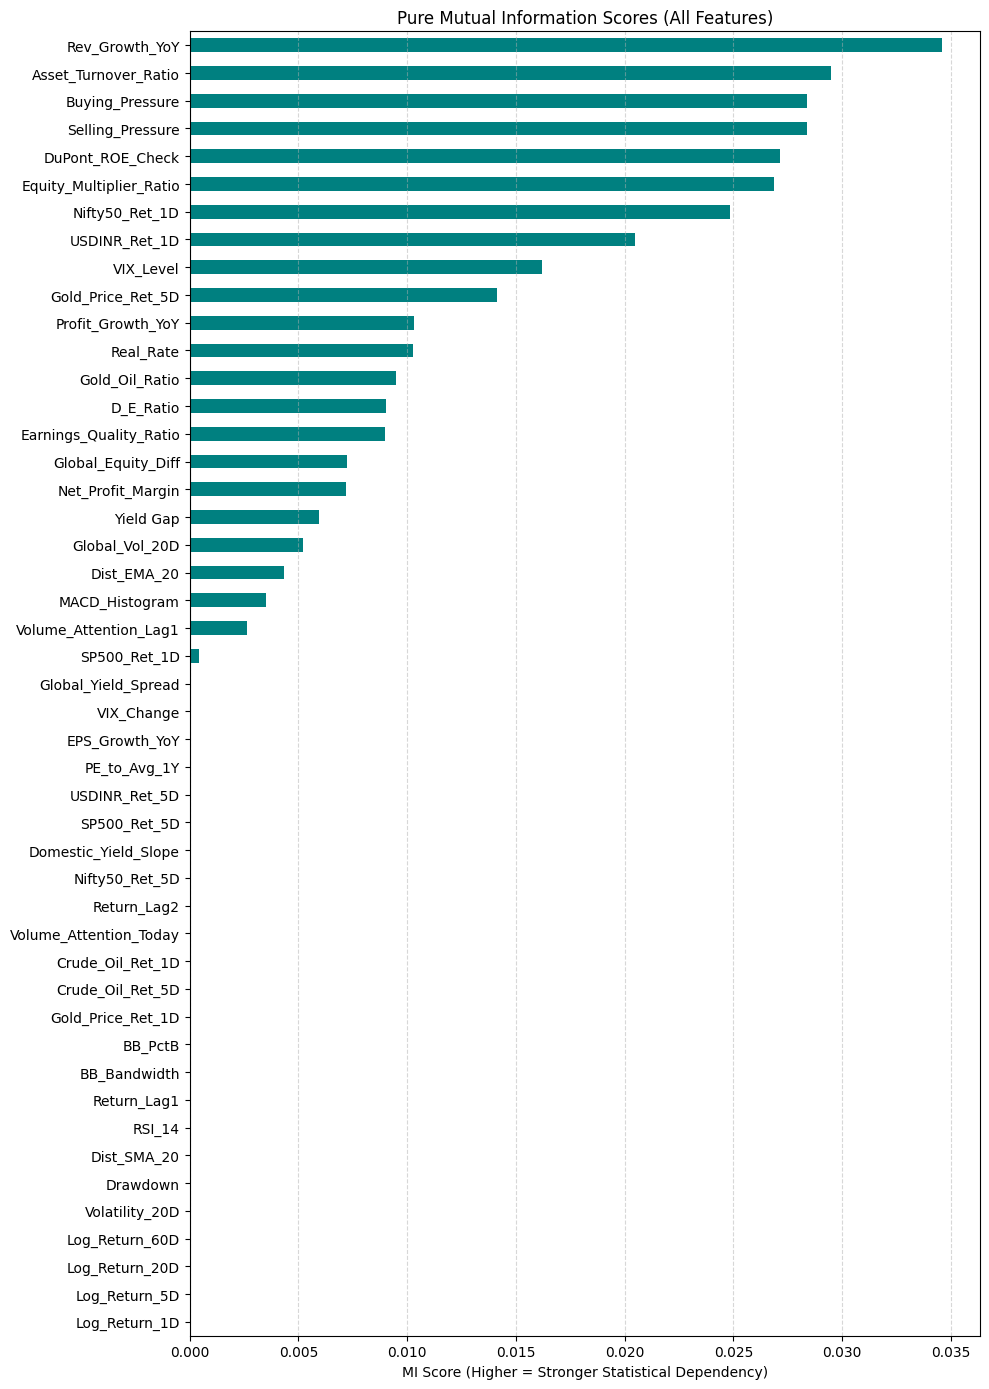


Top 15 Features by MI:
Rev_Growth_YoY             0.034606
Asset_Turnover_Ratio       0.029483
Buying_Pressure            0.028403
Selling_Pressure           0.028403
DuPont_ROE_Check           0.027121
Equity_Multiplier_Ratio    0.026877
Nifty50_Ret_1D             0.024832
USDINR_Ret_1D              0.020477
VIX_Level                  0.016199
Gold_Price_Ret_5D          0.014120
Profit_Growth_YoY          0.010299
Real_Rate                  0.010246
Gold_Oil_Ratio             0.009479
D_E_Ratio                  0.009037
Earnings_Quality_Ratio     0.008997


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

df_wins.index = pd.to_datetime(df_wins.index)
df_wins.index.name = 'Date'

# 3. Dynamically extract feature columns (ignoring Target_Return)
ML_FEATURE_COLS = [col for col in df_wins.columns if col != 'Target_Return']

# 4. Filter for the training period using the INDEX (strictly before Oct 2025)
train_df = df_wins[df_wins.index < '2025-10-01'].copy()

X_train = train_df[ML_FEATURE_COLS].copy()
y_train = train_df['Target_Return'].copy()

# 5. Sanitize: Fix Infs in features and drop NaNs in the target
# # (Uncommented this because MI will crash if any Infs/NaNs slipped through!)
# X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
# X_train.fillna(0, inplace=True)

# valid_idx = y_train.dropna().index
# X_train = X_train.loc[valid_idx]
# y_train = y_train.loc[valid_idx]

# 6. Calculate Mutual Information
print(f"Calculating MI for {len(ML_FEATURE_COLS)} features...")
mi_scores = mutual_info_regression(X_train, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=True)

# 7. Plot all features
plt.figure(figsize=(10, 14))
mi_series.plot(kind='barh', color='teal')
plt.title('Pure Mutual Information Scores (All Features)')
plt.xlabel('MI Score (Higher = Stronger Statistical Dependency)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print the top 15 for quick viewing
print("\nTop 15 Features by MI:")
print(mi_series.tail(15)[::-1].to_string())

Running Spearman Correlation Analysis...

✅ Correlation Filter Complete
   Original Features: 47
   Dropped Redundant: 3
   Features Remaining: 44
   Dropped list: ['Dist_SMA_20', 'Selling_Pressure', 'RSI_14']


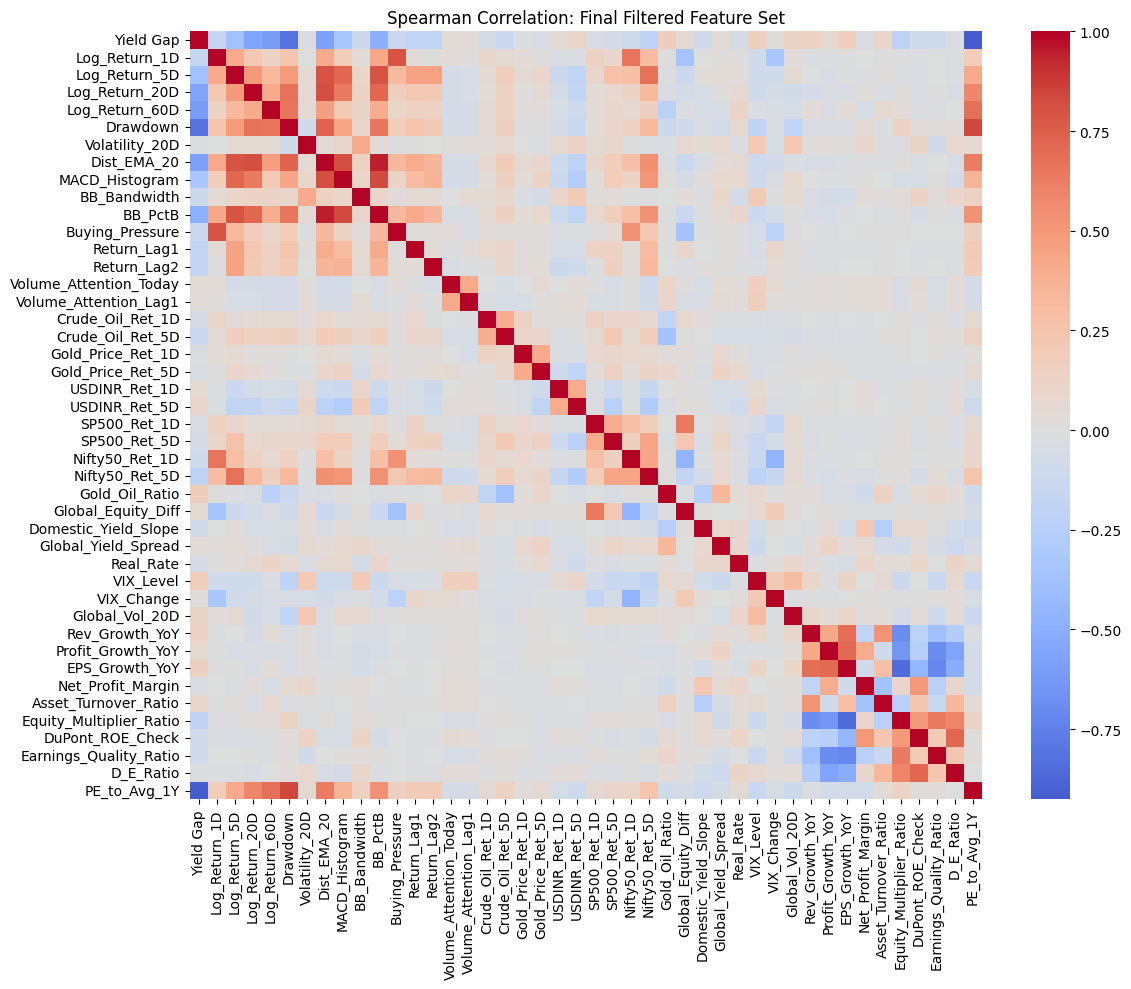

In [83]:
import seaborn as sns


print("Running Spearman Correlation Analysis...")

# 1. Calculate the Spearman Correlation Matrix
# We use Spearman because it captures non-linear but monotonic relationships
corr_matrix = X_train.corr(method='spearman').abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

CORR_THRESHOLD = 0.95
to_drop = set()

# 3. Logic: Between two highly correlated features, keep the one with higher MI score
for col in upper_tri.columns:
    # Find features correlated with the current 'col' above the threshold
    high_corr_vars = upper_tri.index[upper_tri[col] > CORR_THRESHOLD].tolist()
    
    for corr_var in high_corr_vars:
        # Compare their Mutual Information scores (from your previous code block)
        mi_col = mi_series.get(col, 0)
        mi_var = mi_series.get(corr_var, 0)
        
        if mi_col > mi_var:
            to_drop.add(corr_var)
            # print(f"Dropping {corr_var} (Corr with {col} = {upper_tri.loc[corr_var, col]:.2f}, MI {mi_var:.4f} < {mi_col:.4f})")
        else:
            to_drop.add(col)
            # print(f"Dropping {col} (Corr with {corr_var} = {upper_tri.loc[corr_var, col]:.2f}, MI {mi_col:.4f} < {mi_var:.4f})")

# 4. Filter the Training set
X_train_filtered = X_train.drop(columns=list(to_drop))

print(f"\n✅ Correlation Filter Complete")
print(f"   Original Features: {len(X_train.columns)}")
print(f"   Dropped Redundant: {len(to_drop)}")
print(f"   Features Remaining: {len(X_train_filtered.columns)}")
print(f"   Dropped list: {list(to_drop)}")

# 5. Visualize the "Clean" Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_filtered.corr(method='spearman'), cmap='coolwarm', center=0, annot=False)
plt.title('Spearman Correlation: Final Filtered Feature Set')
plt.tight_layout()
plt.show()

# 6. Update the main X_train for the next RFE step
X_train = X_train_filtered.copy()

1. Setting up Overfitting Safeguards (Regularization)...
--- RFE Feature Rankings (Top 15) ---
(Rank 1 = Survived and Selected for Final Model)
               Feature  RFE_Rank
         Log_Return_1D         1
         Log_Return_5D         1
        Log_Return_20D         1
              Drawdown         1
           Dist_EMA_20         1
        Volatility_20D         1
          BB_Bandwidth         1
        MACD_Histogram         1
           Return_Lag1         1
           Return_Lag2         1
               BB_PctB         1
       Buying_Pressure         1
Volume_Attention_Today         1
 Volume_Attention_Lag1         1
      Crude_Oil_Ret_5D         1

--- XGBoost Importance Scores for the 42 Survivors ---
BB_PctB                    0.147003
Nifty50_Ret_1D             0.110675
Asset_Turnover_Ratio       0.099336
Domestic_Yield_Slope       0.094354
Return_Lag2                0.091881
USDINR_Ret_5D              0.078924
USDINR_Ret_1D              0.075950
PE_to_Avg_1Y        

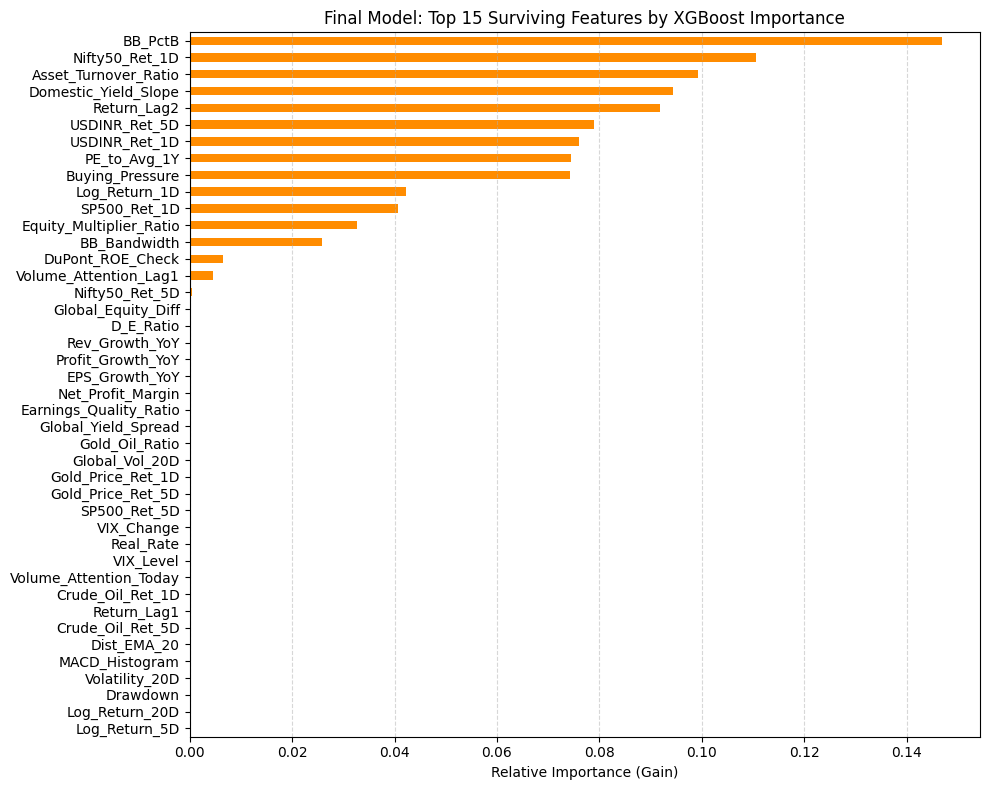


✅ RFE Completed.
Optimal number of features: 42
Dropped 2 features to prevent overfitting.
Dropped Features: ['Yield Gap', 'Log_Return_60D']

Final Selected Features: ['Log_Return_1D', 'Log_Return_5D', 'Log_Return_20D', 'Drawdown', 'Volatility_20D', 'Dist_EMA_20', 'MACD_Histogram', 'BB_Bandwidth', 'BB_PctB', 'Buying_Pressure', 'Return_Lag1', 'Return_Lag2', 'Volume_Attention_Today', 'Volume_Attention_Lag1', 'Crude_Oil_Ret_1D', 'Crude_Oil_Ret_5D', 'Gold_Price_Ret_1D', 'Gold_Price_Ret_5D', 'USDINR_Ret_1D', 'USDINR_Ret_5D', 'SP500_Ret_1D', 'SP500_Ret_5D', 'Nifty50_Ret_1D', 'Nifty50_Ret_5D', 'Gold_Oil_Ratio', 'Global_Equity_Diff', 'Domestic_Yield_Slope', 'Global_Yield_Spread', 'Real_Rate', 'VIX_Level', 'VIX_Change', 'Global_Vol_20D', 'Rev_Growth_YoY', 'Profit_Growth_YoY', 'EPS_Growth_YoY', 'Net_Profit_Margin', 'Asset_Turnover_Ratio', 'Equity_Multiplier_Ratio', 'DuPont_ROE_Check', 'Earnings_Quality_Ratio', 'D_E_Ratio', 'PE_to_Avg_1Y']


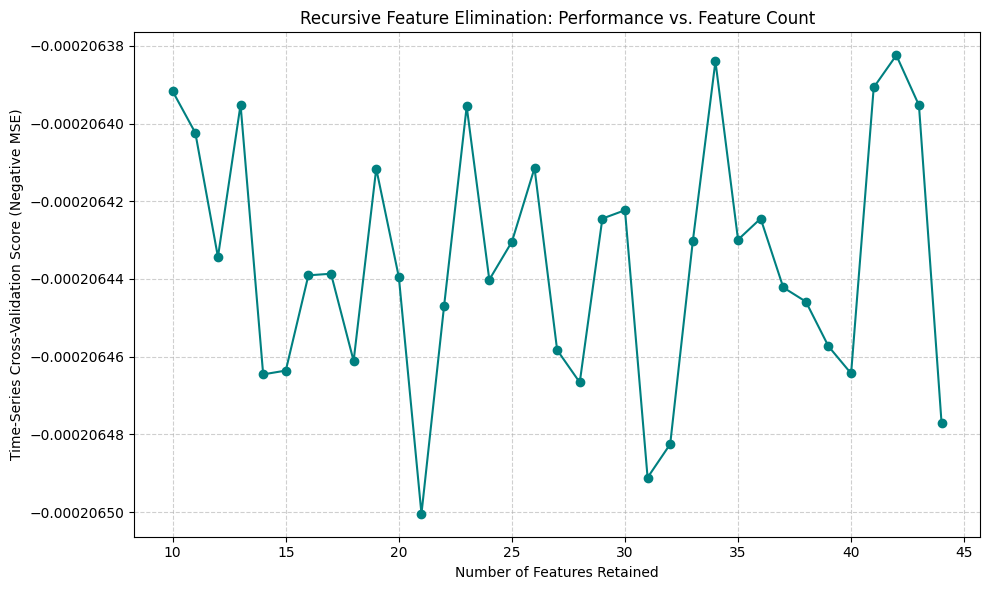

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit

print("1. Setting up Overfitting Safeguards (Regularization)...")

# ============================================================
# SAFEGUARD 1: EXPLICIT REGULARIZATION
# ============================================================
# We define the XGBoost model with strict constraints to prevent "memorizing" noise.
reg_estimator = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,            # SHALLOW TREES: Prevents fitting to extreme outliers
    learning_rate=0.05,
    subsample=0.8,          # ROW SAMPLING: Trains on a random 80% of data each tree
    colsample_bytree=0.8,   # FEATURE SAMPLING: Hides 20% of features each tree
    reg_alpha=1.0,          # L1 REGULARIZATION (Lasso): Pushes weak feature weights to zero
    reg_lambda=1.0,         # L2 REGULARIZATION (Ridge): Prevents any single feature from dominating
    random_state=103,
    n_jobs=-1
)



# TimeSeriesSplit ensures we never train on the future to predict the past
tscv = TimeSeriesSplit(n_splits=5)

# RFECV automatically finds the optimal number of features
selector = RFECV(
    estimator=reg_estimator,
    step=1,                          # Drop the 1 weakest feature at a time
    cv=tscv,                         # Use the strict time-series splits
    scoring='neg_mean_squared_error',# Optimize for lowest error
    min_features_to_select=10       # Don't let it drop below 10 features
)

# Fit RFE on your cleaned X_train and y_train from the previous step
selector.fit(X_train, y_train)
# ============================================================
# EXTRACT RANKINGS AND SCORES
# ============================================================

# 1. The RFE Ranking for ALL original features
# Rank 1 means the feature survived. Rank 2, 3, 4... means it was dropped.
rfe_ranking_df = pd.DataFrame({
    'Feature': X_train.columns,
    'RFE_Rank': selector.ranking_
}).sort_values(by='RFE_Rank')

print("--- RFE Feature Rankings (Top 15) ---")
print("(Rank 1 = Survived and Selected for Final Model)")
print(rfe_ranking_df.head(15).to_string(index=False))
rfe_features = X_train.columns[selector.support_].tolist()

# 2. The XGBoost Importance Score for the SURVIVORS
# selector.estimator_ holds the final XGBoost model trained on the selected features
survivor_importances = pd.Series(
    selector.estimator_.feature_importances_, 
    index=rfe_features
).sort_values(ascending=True)

print(f"\n--- XGBoost Importance Scores for the {len(rfe_features)} Survivors ---")
print(survivor_importances[::-1].to_string())

# 3. Plot the Importance of the Surviving Features
plt.figure(figsize=(10, 8))
survivor_importances.tail(47).plot(kind='barh', color='darkorange')
plt.title('Final Model: Top 15 Surviving Features by XGBoost Importance')
plt.xlabel('Relative Importance (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ============================================================
# RESULTS & VISUALIZATION
# ============================================================
# Extract the final surviving features

print(f"\n✅ RFE Completed.")
print(f"Optimal number of features: {selector.n_features_}")
print(f"Dropped {len(X_train.columns) - selector.n_features_} features to prevent overfitting.")
dropped_features = X_train.columns[~selector.support_].tolist()
print(f"Dropped Features: {dropped_features}")
print(f"\nFinal Selected Features: {rfe_features}")

# Plot the RFE Curve to show in your assignment report
plt.figure(figsize=(10, 6))
# RFECV cv_results_ changed in recent sklearn versions, safely extract mean test scores
try:
    scores = selector.cv_results_['mean_test_score']
except KeyError:
    scores = selector.grid_scores_ # Fallback for older sklearn versions

plt.plot(range(10, len(scores) + 10), scores, marker='o', color='teal')
plt.title('Recursive Feature Elimination: Performance vs. Feature Count')
plt.xlabel('Number of Features Retained')
plt.ylabel('Time-Series Cross-Validation Score (Negative MSE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Update your training data to ONLY include the RFE-approved features
X_train_final = X_train[rfe_features]

Generating SHAP Summary Plot...


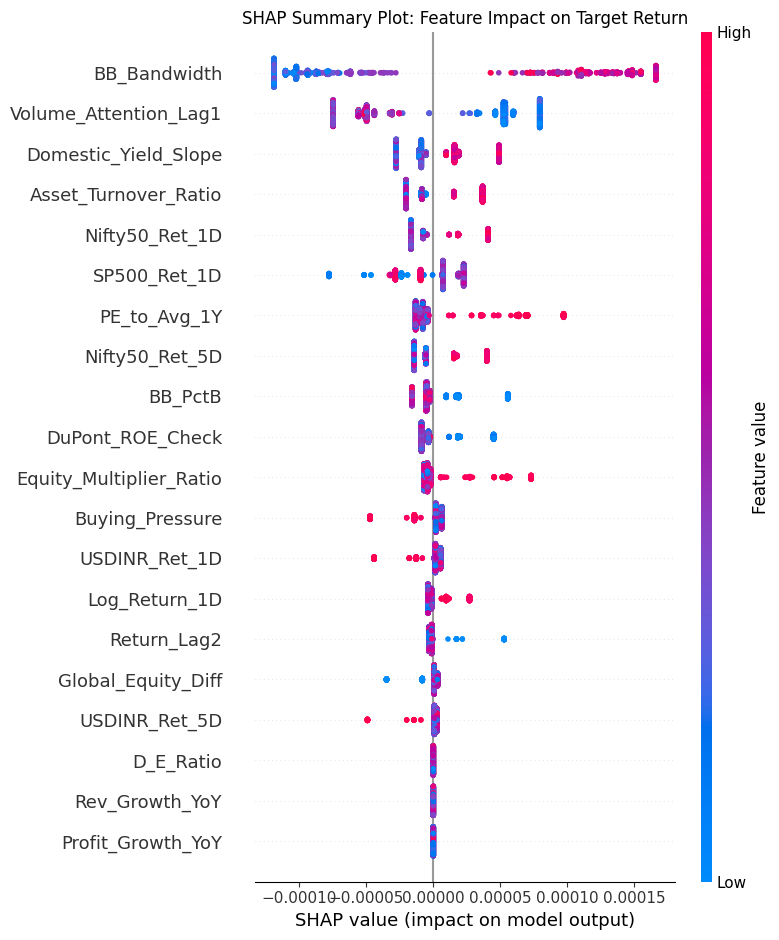

In [85]:
import shap
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# 2. SHAP (Directional Interpretability)
# ============================================================
print("Generating SHAP Summary Plot...")
# selector.estimator_ is your final, regularized model trained only on the best features
explainer = shap.TreeExplainer(selector.estimator_)
shap_values = explainer.shap_values(X_train_final)

plt.figure(figsize=(10, 8))
# plot_type="dot" creates the classic red/blue beeswarm plot
shap.summary_plot(shap_values, X_train_final, plot_type="dot", show=False)
plt.title('SHAP Summary Plot: Feature Impact on Target Return')
plt.tight_layout()
plt.show()

In [145]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# 1. Prepare the final data matrices
# X_train_final and rfe_features should be from your 0.05 LR run
X_production = X_train[rfe_features].copy()
y_production = y_train.copy()

# 2. Create a 20% validation split from the end of the training data
split_idx = int(len(X_production) * 0.9)
X_train_sub, X_val = X_production.iloc[:split_idx], X_production.iloc[split_idx:]
y_train_sub, y_val = y_production.iloc[:split_idx], y_production.iloc[split_idx:]

final_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,      # Dropped back to 0.05 for better stability than 0.09
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,          # FIXED: Scaled down for decimal targets
    reg_lambda=0.1,         # FIXED: Scaled down for decimal targets
    random_state=100,
    n_jobs=1,
    objective="reg:squarederror",
    tree_method="hist",
    eval_metric="rmse",
    early_stopping_rounds=1000, 
)
# 4. Fit with Early Stopping
print("Training with Early Stopping to find optimal trees...")
final_model.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_trees = final_model.best_iteration+1
print(f"✅ Optimal number of trees found: {best_trees}")

# 5. Re-train on 100% of Training Data (The 'Production' Model)
# This model will be used for the Q4 2025 Out-of-Sample Backtest
params = final_model.get_params()

# Remove early stopping parameter completely
params.pop("early_stopping_rounds", None)

prod_model = xgb.XGBRegressor(**params)

prod_model.set_params(n_estimators=best_trees)

prod_model.fit(X_production, y_production)

print("🚀 Production model trained and ready for Q4 2025 Backtest.")

Training with Early Stopping to find optimal trees...
✅ Optimal number of trees found: 38
🚀 Production model trained and ready for Q4 2025 Backtest.


In [146]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_train_pred = prod_model.predict(X_production)

rmse_train = np.sqrt(mean_squared_error(y_production, y_train_pred))
mae_train = mean_absolute_error(y_production, y_train_pred)
r2_train = r2_score(y_production, y_train_pred)

print("Train RMSE:", rmse_train)
print("Train MAE:", mae_train)
print("Train R²:", r2_train)

Train RMSE: 0.016520962962847937
Train MAE: 0.011430330376533385
Train R²: 0.15236827821301246


In [147]:
test_df = df_wins[(df_wins.index >= '2025-10-01') & (df_wins.index < '2025-12-30')].copy()


X_test = test_df[rfe_features].copy()
y_test = test_df['Target_Return'].copy()

y_test_pred = prod_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)
print("Test R²:", r2_test)

Test RMSE: 0.008570967329310494
Test MAE: 0.006538858643472366
Test R²: 0.1361893526359904


In [148]:
import numpy as np
from sklearn.metrics import mean_squared_error

baseline_pred = np.zeros_like(y_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline RMSE:", baseline_rmse)
print("Model RMSE:", rmse_test)

Baseline RMSE: 0.009428552564480797
Model RMSE: 0.008570967329310494


In [149]:
direction_acc = np.mean(
    np.sign(y_test_pred) == np.sign(y_test)
)
direction_acc

np.float64(0.55)

In [141]:
corr = np.corrcoef(y_test, y_test_pred)[0,1]
corr

np.float64(0.4351666376467338)

FInal Model

In [158]:
import pandas as pd
import numpy as np
import os
import glob
from feature_engine.outliers import Winsorizer

# =======================================================
# 1. LOAD, ADD TARGET, AND MERGE
# =======================================================
print("1. Compiling Stock Panel Data...")
csv_files = glob.glob(r"C:\Users\91983\Downloads\features\*.csv") 

all_dfs = []
for file in csv_files:
    # Extract ticker from filename (e.g., 'features\hdfc.csv' -> 'HDFC')
    ticker_name = os.path.basename(file).split('.')[0].upper()
    
    df = pd.read_csv(file)
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Add Ticker Column
    df['Ticker'] = ticker_name
    
    # Sort strictly by date before shifting to prevent errors
    df.sort_values('Date', inplace=True)
    
    # CALCULATE TARGET: Tomorrow's Log Return
    df['Target_Return'] = df['Log_Return_1D'].shift(-1)
    
    # Drop the very last row (since tomorrow hasn't happened yet)
    df.dropna(subset=['Target_Return'], inplace=True)
    
    all_dfs.append(df)

# Combine into one massive panel
df_panel = pd.concat(all_dfs, ignore_index=True)

# THE GOLDEN RULE: Sort by Date, then Ticker for TimeSeriesSplit
df_panel.sort_values(by=['Date', 'Ticker'], inplace=True)
df_panel.reset_index(drop=True, inplace=True)

print(f"✅ Panel Merged. Total Rows: {len(df_panel)}")

# =======================================================
# 2. WINSORIZE (FEATURES ONLY)
# =======================================================
print("2. Winsorizing Features (1st-99th Percentile)...")

# 1. SETUP: Identify features (Exclude non-numeric and Target)
# Notice we are leaving 'Ticker' intact for the next step!
exclude_cols = ['Date', 'Ticker', 'Target_Return', 'Unnamed: 0'] # Added Unnamed:0 just in case
candidate_features = [c for c in df_panel.columns if c not in exclude_cols]

# 2. WINSORIZATION
winsorizer = Winsorizer(capping_method='quantiles', tail='both', 
                        fold=0.01, variables=candidate_features)
df_panel.fillna(-0.00382, inplace=True)
df_panel_wins = winsorizer.fit_transform(df_panel)

# =======================================================
# 3. SMART ROLLING/EXPANDING NORMALIZATION
# =======================================================
print("3. Applying Smart Normalization (Grouped by Ticker)...")

def smart_rolling_normalize(df, columns, window=30):
    df_norm = df.copy()
    
    for col in columns:
        # 1. MUST group by Ticker to prevent mixing different stocks
        rolling_std = df_norm.groupby('Ticker')[col].transform(lambda x: x.rolling(window=window).std())
        
        # 2. Check for zero variance (Fundamentals)
        if (rolling_std == 0).any():
            # Expanding Z-Score grouped by Ticker
            mean = df_norm.groupby('Ticker')[col].transform(lambda x: x.expanding().mean())
            std = df_norm.groupby('Ticker')[col].transform(lambda x: x.expanding().std()) + 1e-8
            df_norm[col] = (df_norm[col] - mean) / std
        else:
            # 30-Day Rolling Z-Score grouped by Ticker
            mean = df_norm.groupby('Ticker')[col].transform(lambda x: x.rolling(window=window).mean())
            df_norm[col] = (df_norm[col] - mean) / (rolling_std + 1e-8)
            
    return df_norm

df_panel_norm = smart_rolling_normalize(df_panel_wins, candidate_features, window=30)

# Drop NaNs created by the initial 30-day rolling windows
df_panel_norm.dropna(inplace=True)

# =======================================================
# 4. ONE-HOT ENCODING & FINAL CLEANUP
# =======================================================
print("4. Applying One-Hot Encoding for Tickers...")

# Now that normalization is done, we can safely split the Ticker column
df_final = pd.get_dummies(df_panel_norm, columns=['Ticker'], drop_first=False, dtype=int)

# Set Date as index so it isn't fed into XGBoost as a feature
df_final.set_index('Date', inplace=True)

print(f"🚀 Pipeline Complete! Final Active Rows: {len(df_final)}, Features: {len(df_final.columns)}")

# Save to disk
df_final.to_csv("FINAL_MASTER_PANEL.csv")

1. Compiling Stock Panel Data...
✅ Panel Merged. Total Rows: 8805
2. Winsorizing Features (1st-99th Percentile)...
3. Applying Smart Normalization (Grouped by Ticker)...
4. Applying One-Hot Encoding for Tickers...
🚀 Pipeline Complete! Final Active Rows: 8631, Features: 54


In [215]:
df_final.columns

Index(['Log_Return_1D', 'Log_Return_5D', 'Log_Return_20D', 'Log_Return_60D',
       'Drawdown', 'Dist_SMA_20', 'Dist_EMA_20', 'RSI_14', 'MACD_Histogram',
       'BB_Bandwidth', 'BB_PctB', 'Buying_Pressure', 'Selling_Pressure',
       'Return_Lag1', 'Return_Lag2', 'Volume_Attention_Today',
       'Volume_Attention_Lag1', 'Yield Gap', 'Crude_Oil_Ret_1D',
       'Crude_Oil_Ret_5D', 'Gold_Price_Ret_1D', 'Gold_Price_Ret_5D',
       'USDINR_Ret_1D', 'USDINR_Ret_5D', 'SP500_Ret_1D', 'SP500_Ret_5D',
       'Nifty50_Ret_1D', 'Nifty50_Ret_5D', 'Gold_Oil_Ratio',
       'Global_Equity_Diff', 'Domestic_Yield_Slope', 'Global_Yield_Spread',
       'Real_Rate', 'VIX_Level', 'VIX_Change', 'Global_Vol_20D',
       'Rev_Growth_YoY', 'Profit_Growth_YoY', 'EPS_Growth_YoY',
       'Net_Profit_Margin', 'Asset_Turnover_Ratio', 'Equity_Multiplier_Ratio',
       'DuPont_ROE_Check', 'Earnings_Quality_Ratio', 'D_E_Ratio',
       'PE_to_Avg_1Y', 'avg_sentiment', 'Target_Return', 'Ticker_AIRTEL',
       'Ticker_HDF

Calculating MI for 47 features...


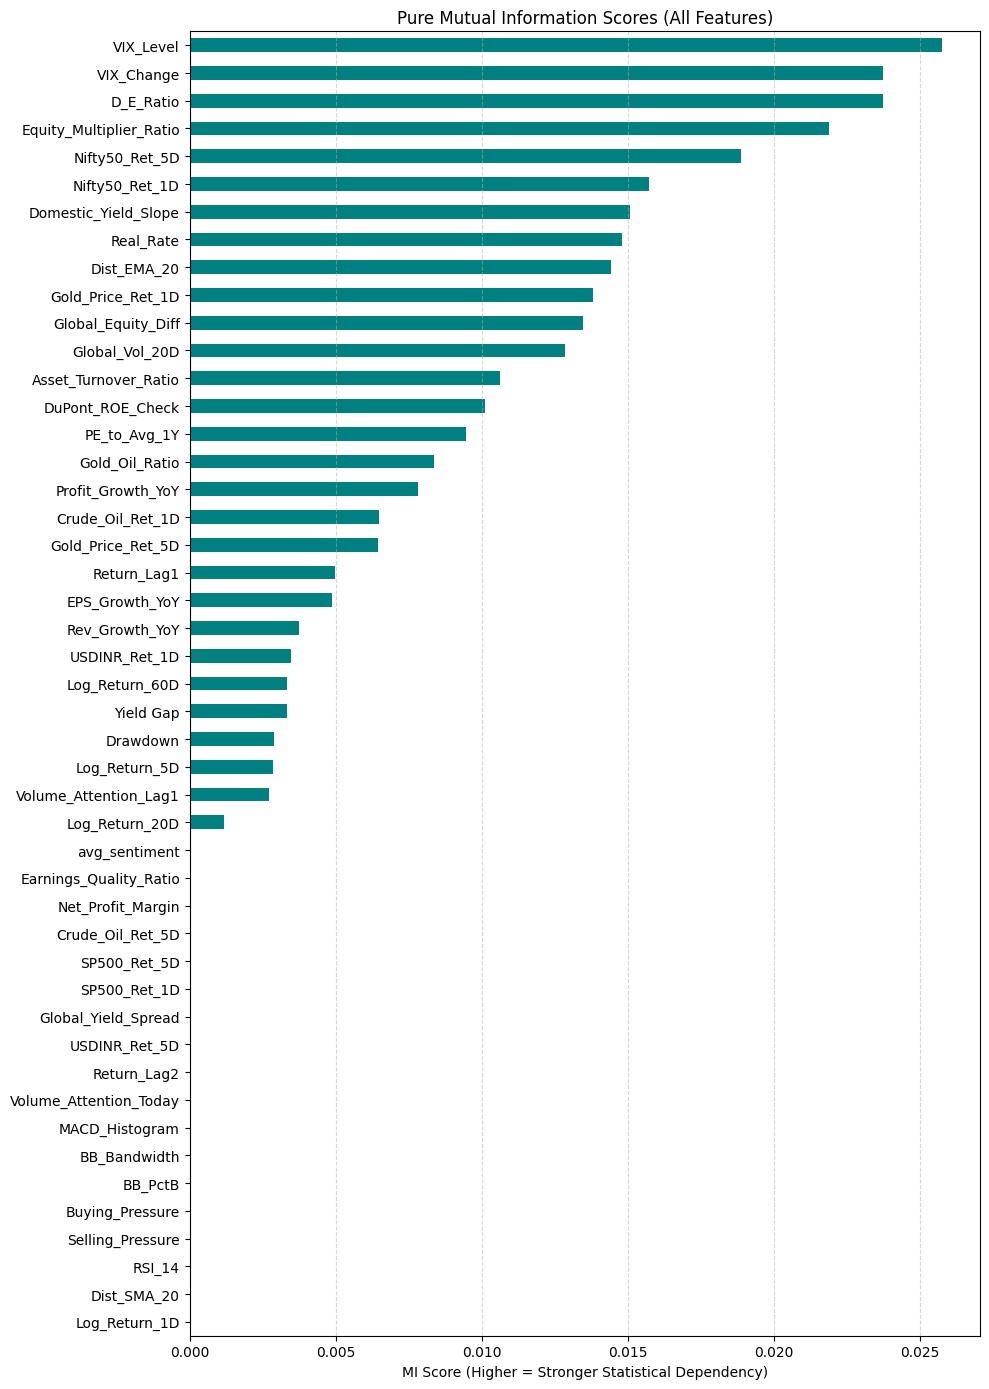


Top 15 Features by MI:
VIX_Level                  0.025764
VIX_Change                 0.023740
D_E_Ratio                  0.023728
Equity_Multiplier_Ratio    0.021873
Nifty50_Ret_5D             0.018860
Nifty50_Ret_1D             0.015739
Domestic_Yield_Slope       0.015075
Real_Rate                  0.014803
Dist_EMA_20                0.014429
Gold_Price_Ret_1D          0.013817
Global_Equity_Diff         0.013449
Global_Vol_20D             0.012849
Asset_Turnover_Ratio       0.010634
DuPont_ROE_Check           0.010108
PE_to_Avg_1Y               0.009471


In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

df_final.index = pd.to_datetime(df_final.index)
df_final.index.name = 'Date'

# 3. Dynamically extract feature columns (ignoring Target_Return)
ML_FEATURE_COLS = [col for col in df_final.columns if col != 'Target_Return'and not col.startswith('Ticker_')]

# 4. Filter for the training period using the INDEX (strictly before Oct 2025)
train_df = df_final[df_final.index < '2025-10-01'].copy()

X_train = train_df[ML_FEATURE_COLS].copy()
y_train = train_df['Target_Return'].copy()

# 5. Sanitize: Fix Infs in features and drop NaNs in the target
# # (Uncommented this because MI will crash if any Infs/NaNs slipped through!)
# X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
# X_train.fillna(0, inplace=True)

# valid_idx = y_train.dropna().index
# X_train = X_train.loc[valid_idx]
# y_train = y_train.loc[valid_idx]

# 6. Calculate Mutual Information
print(f"Calculating MI for {len(ML_FEATURE_COLS)} features...")
mi_scores = mutual_info_regression(X_train, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=True)

# 7. Plot all features
plt.figure(figsize=(10, 14))
mi_series.plot(kind='barh', color='teal')
plt.title('Pure Mutual Information Scores (All Features)')
plt.xlabel('MI Score (Higher = Stronger Statistical Dependency)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print the top 15 for quick viewing
print("\nTop 15 Features by MI:")
print(mi_series.tail(15)[::-1].to_string())

Running Spearman Correlation Analysis...

✅ Correlation Filter Complete
   Original Features: 47
   Dropped Redundant: 3
   Features Remaining: 44
   Dropped list: ['Dist_SMA_20', 'Selling_Pressure', 'RSI_14']


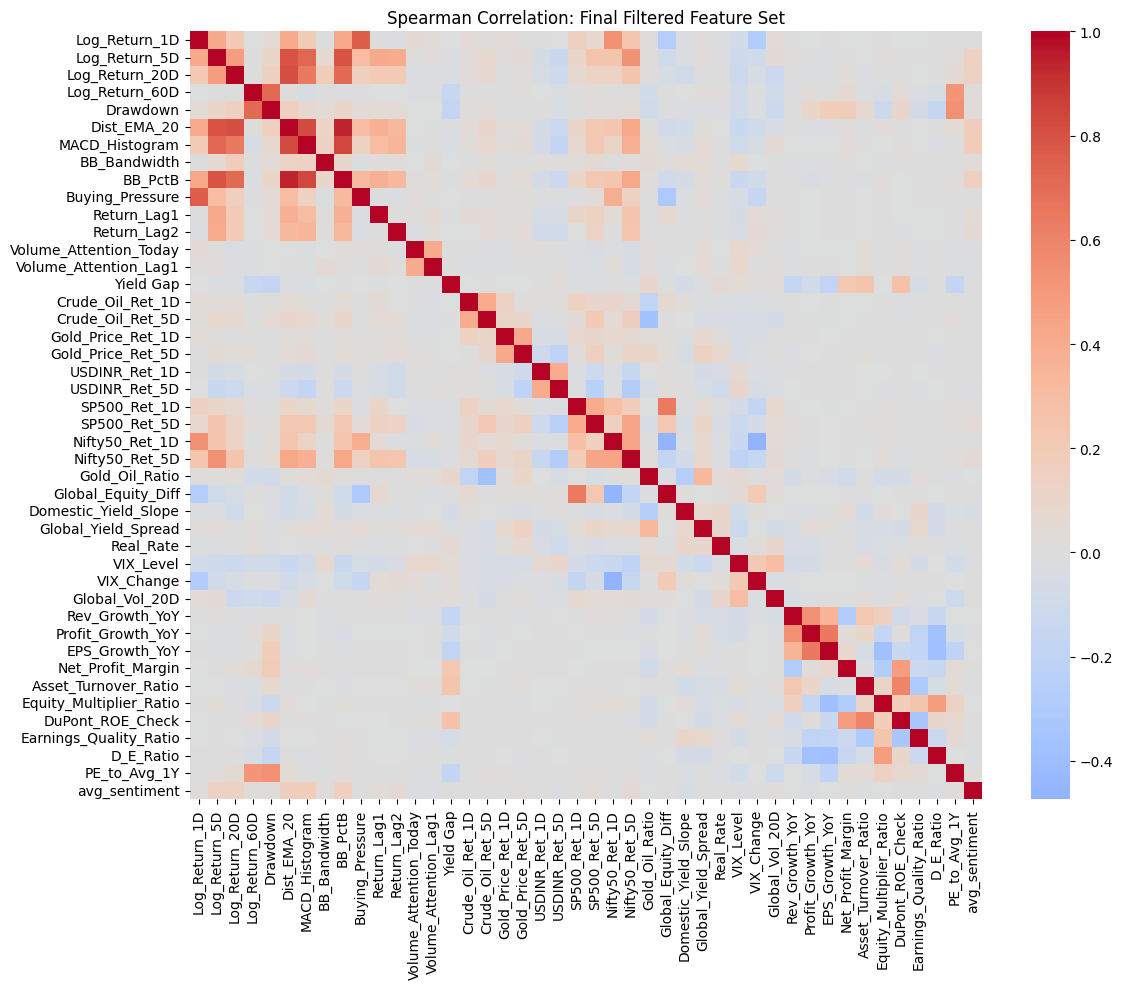

In [217]:
import seaborn as sns


print("Running Spearman Correlation Analysis...")

# 1. Calculate the Spearman Correlation Matrix
# We use Spearman because it captures non-linear but monotonic relationships
corr_matrix = X_train.corr(method='spearman').abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

CORR_THRESHOLD = 0.95
to_drop = set()

# 3. Logic: Between two highly correlated features, keep the one with higher MI score
for col in upper_tri.columns:
    # Find features correlated with the current 'col' above the threshold
    high_corr_vars = upper_tri.index[upper_tri[col] > CORR_THRESHOLD].tolist()
    
    for corr_var in high_corr_vars:
        # Compare their Mutual Information scores (from your previous code block)
        mi_col = mi_series.get(col, 0)
        mi_var = mi_series.get(corr_var, 0)
        
        if mi_col > mi_var:
            to_drop.add(corr_var)
            # print(f"Dropping {corr_var} (Corr with {col} = {upper_tri.loc[corr_var, col]:.2f}, MI {mi_var:.4f} < {mi_col:.4f})")
        else:
            to_drop.add(col)
            # print(f"Dropping {col} (Corr with {corr_var} = {upper_tri.loc[corr_var, col]:.2f}, MI {mi_col:.4f} < {mi_var:.4f})")

# 4. Filter the Training set
X_train_filtered = X_train.drop(columns=list(to_drop))

print(f"\n✅ Correlation Filter Complete")
print(f"   Original Features: {len(X_train.columns)}")
print(f"   Dropped Redundant: {len(to_drop)}")
print(f"   Features Remaining: {len(X_train_filtered.columns)}")
print(f"   Dropped list: {list(to_drop)}")

# 5. Visualize the "Clean" Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_filtered.corr(method='spearman'), cmap='coolwarm', center=0, annot=False)
plt.title('Spearman Correlation: Final Filtered Feature Set')
plt.tight_layout()
plt.show()

# 6. Update the main X_train for the next RFE step
X_train = X_train_filtered.copy()

1. Setting up Overfitting Safeguards (Regularization)...
--- RFE Feature Rankings (Top 15) ---
(Rank 1 = Survived and Selected for Final Model)
              Feature  RFE_Rank
        Log_Return_1D         1
        Log_Return_5D         1
       Log_Return_20D         1
       Log_Return_60D         1
             Drawdown         1
          Dist_EMA_20         1
       MACD_Histogram         1
         BB_Bandwidth         1
              BB_PctB         1
      Buying_Pressure         1
          Return_Lag2         1
Volume_Attention_Lag1         1
     Crude_Oil_Ret_1D         1
            Yield Gap         1
    Gold_Price_Ret_1D         1

--- XGBoost Importance Scores for the 39 Survivors ---
Nifty50_Ret_5D             0.096060
Return_Lag2                0.058725
Crude_Oil_Ret_1D           0.039905
Yield Gap                  0.038939
Gold_Oil_Ratio             0.035065
Nifty50_Ret_1D             0.032932
Crude_Oil_Ret_5D           0.032761
Log_Return_60D             0.030989


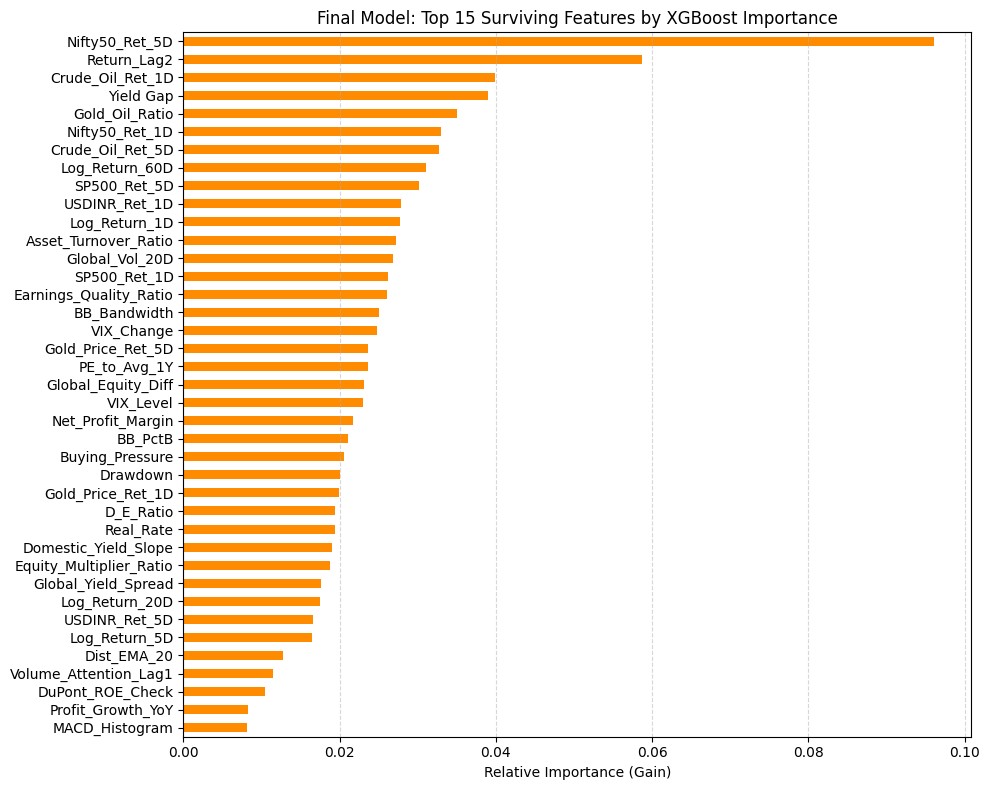


✅ RFE Completed.
Optimal number of features: 39
Dropped 5 features to prevent overfitting.
Dropped Features: ['Return_Lag1', 'Volume_Attention_Today', 'Rev_Growth_YoY', 'EPS_Growth_YoY', 'avg_sentiment']

Final Selected Features: ['Log_Return_1D', 'Log_Return_5D', 'Log_Return_20D', 'Log_Return_60D', 'Drawdown', 'Dist_EMA_20', 'MACD_Histogram', 'BB_Bandwidth', 'BB_PctB', 'Buying_Pressure', 'Return_Lag2', 'Volume_Attention_Lag1', 'Yield Gap', 'Crude_Oil_Ret_1D', 'Crude_Oil_Ret_5D', 'Gold_Price_Ret_1D', 'Gold_Price_Ret_5D', 'USDINR_Ret_1D', 'USDINR_Ret_5D', 'SP500_Ret_1D', 'SP500_Ret_5D', 'Nifty50_Ret_1D', 'Nifty50_Ret_5D', 'Gold_Oil_Ratio', 'Global_Equity_Diff', 'Domestic_Yield_Slope', 'Global_Yield_Spread', 'Real_Rate', 'VIX_Level', 'VIX_Change', 'Global_Vol_20D', 'Profit_Growth_YoY', 'Net_Profit_Margin', 'Asset_Turnover_Ratio', 'Equity_Multiplier_Ratio', 'DuPont_ROE_Check', 'Earnings_Quality_Ratio', 'D_E_Ratio', 'PE_to_Avg_1Y']


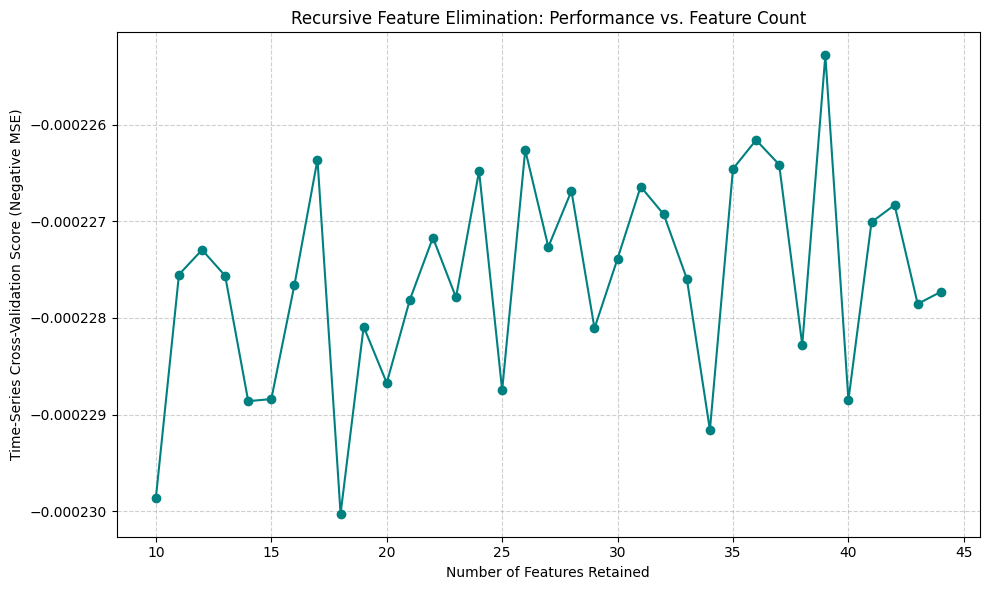

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit

print("1. Setting up Overfitting Safeguards (Regularization)...")

# ============================================================
# SAFEGUARD 1: EXPLICIT REGULARIZATION
# ============================================================
# We define the XGBoost model with strict constraints to prevent "memorizing" noise.
reg_estimator = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,            # SHALLOW TREES: Prevents fitting to extreme outliers
    learning_rate=0.05,
    subsample=0.8,          # ROW SAMPLING: Trains on a random 80% of data each tree
    colsample_bytree=0.8,   # FEATURE SAMPLING: Hides 20% of features each tree
    reg_alpha=0.1,          # L1 REGULARIZATION (Lasso): Pushes weak feature weights to zero
    reg_lambda=0.1,         # L2 REGULARIZATION (Ridge): Prevents any single feature from dominating
    random_state=100,
    n_jobs=-1
)



# TimeSeriesSplit ensures we never train on the future to predict the past
tscv = TimeSeriesSplit(n_splits=5)

# RFECV automatically finds the optimal number of features
selector = RFECV(
    estimator=reg_estimator,
    step=1,                          # Drop the 1 weakest feature at a time
    cv=tscv,                         # Use the strict time-series splits
    scoring='neg_mean_squared_error',# Optimize for lowest error
    min_features_to_select=10       # Don't let it drop below 10 features
)

# Fit RFE on your cleaned X_train and y_train from the previous step
selector.fit(X_train, y_train)
# ============================================================
# EXTRACT RANKINGS AND SCORES
# ============================================================

# 1. The RFE Ranking for ALL original features
# Rank 1 means the feature survived. Rank 2, 3, 4... means it was dropped.
rfe_ranking_df = pd.DataFrame({
    'Feature': X_train.columns,
    'RFE_Rank': selector.ranking_
}).sort_values(by='RFE_Rank')

print("--- RFE Feature Rankings (Top 15) ---")
print("(Rank 1 = Survived and Selected for Final Model)")
print(rfe_ranking_df.head(15).to_string(index=False))
rfe_features = X_train.columns[selector.support_].tolist()

# 2. The XGBoost Importance Score for the SURVIVORS
# selector.estimator_ holds the final XGBoost model trained on the selected features
survivor_importances = pd.Series(
    selector.estimator_.feature_importances_, 
    index=rfe_features
).sort_values(ascending=True)

print(f"\n--- XGBoost Importance Scores for the {len(rfe_features)} Survivors ---")
print(survivor_importances[::-1].to_string())

# 3. Plot the Importance of the Surviving Features
plt.figure(figsize=(10, 8))
survivor_importances.plot(kind='barh', color='darkorange')
plt.title('Final Model: Top 15 Surviving Features by XGBoost Importance')
plt.xlabel('Relative Importance (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ============================================================
# RESULTS & VISUALIZATION
# ============================================================
# Extract the final surviving features

print(f"\n✅ RFE Completed.")
print(f"Optimal number of features: {selector.n_features_}")
print(f"Dropped {len(X_train.columns) - selector.n_features_} features to prevent overfitting.")
dropped_features = X_train.columns[~selector.support_].tolist()
print(f"Dropped Features: {dropped_features}")
print(f"\nFinal Selected Features: {rfe_features}")

# Plot the RFE Curve to show in your assignment report
plt.figure(figsize=(10, 6))
# RFECV cv_results_ changed in recent sklearn versions, safely extract mean test scores
try:
    scores = selector.cv_results_['mean_test_score']
except KeyError:
    scores = selector.grid_scores_ # Fallback for older sklearn versions

plt.plot(range(10, len(scores) + 10), scores, marker='o', color='teal')
plt.title('Recursive Feature Elimination: Performance vs. Feature Count')
plt.xlabel('Number of Features Retained')
plt.ylabel('Time-Series Cross-Validation Score (Negative MSE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Generating SHAP Summary Plot...


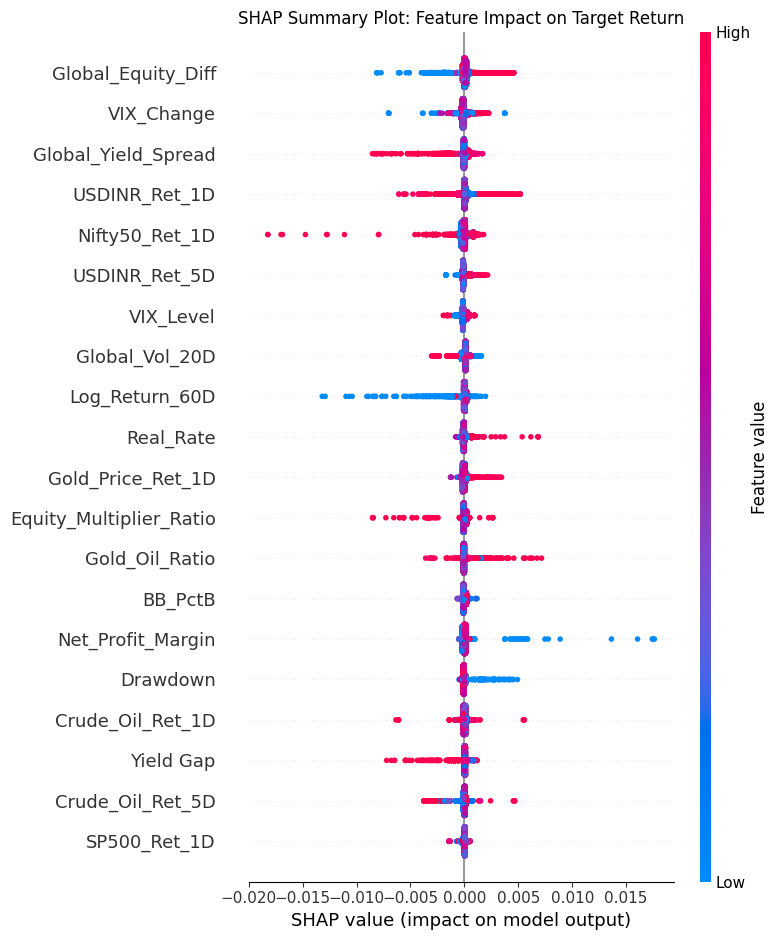

In [237]:
import shap
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# 2. SHAP (Directional Interpretability)
# ============================================================
print("Generating SHAP Summary Plot...")
# selector.estimator_ is your final, regularized model trained only on the best features
explainer = shap.TreeExplainer(selector.estimator_)
shap_values = explainer.shap_values(X_train_final)

plt.figure(figsize=(10, 8))
# plot_type="dot" creates the classic red/blue beeswarm plot
shap.summary_plot(shap_values, X_train_final, plot_type="dot", show=False)
plt.title('SHAP Summary Plot: Feature Impact on Target Return')
plt.tight_layout()
plt.show()

In [473]:
rfe_features=rfe_features+['avg_sentiment','Ticker_AIRTEL',
       'Ticker_HDFC', 'Ticker_HUL', 'Ticker_INFY', 'Ticker_MANDM',
       'Ticker_RELIANCE']


# features = [
#     'avg_sentiment',
#     'Ticker_AIRTEL',
#     'Ticker_HDFC',
#     'Ticker_HUL',
#     'Ticker_INFY',
#     'Ticker_MANDM',
#     'Ticker_RELIANCE'
# ]
# rfe_features = [f for f in rfe_features if f not in features]
train_df[rfe_features]

,Log_Return_1D,Log_Return_5D,Log_Return_20D,Log_Return_60D,Drawdown,Dist_EMA_20,MACD_Histogram,BB_Bandwidth,BB_PctB,Buying_Pressure,...,Earnings_Quality_Ratio,D_E_Ratio,PE_to_Avg_1Y,avg_sentiment,Ticker_AIRTEL,Ticker_HDFC,Ticker_HUL,Ticker_INFY,Ticker_MANDM,Ticker_RELIANCE
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-13,-0.272437,-0.807149,0.653961,-0.882561,0.159511,0.019807,-0.045593,-0.185283,-0.175866,0.734215,...,0.000000,0.000000,1.503236,-1.214103,1,0,0,0,0,0
2020-02-13,-0.395995,0.292390,-0.788446,-1.014736,-0.339144,0.528419,1.658775,-0.467679,0.944608,-0.891848,...,0.000000,0.000000,-0.812377,-0.378837,0,1,0,0,0,0
2020-02-13,0.396486,1.398605,1.098435,2.706049,1.405039,1.956489,0.745524,1.446206,0.902026,1.200538,...,0.000000,0.000000,2.209323,0.946824,0,0,1,0,0,0
2020-02-13,0.254153,-1.928109,-2.194786,-0.116170,-1.145039,-1.593366,-2.431244,1.340139,-1.658716,0.039819,...,0.000000,0.000000,-1.748461,-1.247836,0,0,0,0,1,0
2020-02-13,0.253636,0.675405,-0.271129,-1.528156,-0.416096,0.830635,1.615604,1.292974,0.795073,1.159865,...,0.000000,0.000000,-0.393782,-0.745860,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-30,0.397998,0.065357,1.879031,-0.607432,0.410539,0.097960,0.124277,-1.006652,-0.326797,-0.305081,...,1.615833,-2.245831,1.073776,0.638201,0,1,0,0,0,0
2025-09-30,0.690805,-0.148986,-1.674240,0.653780,-0.439858,-1.076202,-0.852674,-0.357963,-0.866697,0.895789,...,-0.105054,1.439445,0.314196,-0.702259,0,0,1,0,0,0
2025-09-30,-0.006203,-1.189804,-1.021615,-1.209003,-1.763592,-1.569968,-2.345902,-0.004525,-1.841631,-0.552989,...,1.905179,0.135433,-1.424419,-2.056743,0,0,0,1,0,0


In [474]:
X_train_final=train_df[rfe_features].copy()

In [475]:
X_train_final

,Log_Return_1D,Log_Return_5D,Log_Return_20D,Log_Return_60D,Drawdown,Dist_EMA_20,MACD_Histogram,BB_Bandwidth,BB_PctB,Buying_Pressure,...,Earnings_Quality_Ratio,D_E_Ratio,PE_to_Avg_1Y,avg_sentiment,Ticker_AIRTEL,Ticker_HDFC,Ticker_HUL,Ticker_INFY,Ticker_MANDM,Ticker_RELIANCE
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-13,-0.272437,-0.807149,0.653961,-0.882561,0.159511,0.019807,-0.045593,-0.185283,-0.175866,0.734215,...,0.000000,0.000000,1.503236,-1.214103,1,0,0,0,0,0
2020-02-13,-0.395995,0.292390,-0.788446,-1.014736,-0.339144,0.528419,1.658775,-0.467679,0.944608,-0.891848,...,0.000000,0.000000,-0.812377,-0.378837,0,1,0,0,0,0
2020-02-13,0.396486,1.398605,1.098435,2.706049,1.405039,1.956489,0.745524,1.446206,0.902026,1.200538,...,0.000000,0.000000,2.209323,0.946824,0,0,1,0,0,0
2020-02-13,0.254153,-1.928109,-2.194786,-0.116170,-1.145039,-1.593366,-2.431244,1.340139,-1.658716,0.039819,...,0.000000,0.000000,-1.748461,-1.247836,0,0,0,0,1,0
2020-02-13,0.253636,0.675405,-0.271129,-1.528156,-0.416096,0.830635,1.615604,1.292974,0.795073,1.159865,...,0.000000,0.000000,-0.393782,-0.745860,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-30,0.397998,0.065357,1.879031,-0.607432,0.410539,0.097960,0.124277,-1.006652,-0.326797,-0.305081,...,1.615833,-2.245831,1.073776,0.638201,0,1,0,0,0,0
2025-09-30,0.690805,-0.148986,-1.674240,0.653780,-0.439858,-1.076202,-0.852674,-0.357963,-0.866697,0.895789,...,-0.105054,1.439445,0.314196,-0.702259,0,0,1,0,0,0
2025-09-30,-0.006203,-1.189804,-1.021615,-1.209003,-1.763592,-1.569968,-2.345902,-0.004525,-1.841631,-0.552989,...,1.905179,0.135433,-1.424419,-2.056743,0,0,0,1,0,0


In [486]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# 1. Prepare the final data matrices
# X_train_final and rfe_features should be from your 0.05 LR run
X_production = X_train_final.copy()
y_production = y_train.copy()

# 2. Create a 20% validation split from the end of the training data
split_idx = int(len(X_production) * 0.9)
X_train_sub, X_val = X_production.iloc[:split_idx], X_production.iloc[split_idx:]
y_train_sub, y_val = y_production.iloc[:split_idx], y_production.iloc[split_idx:]

final_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,      # Dropped back to 0.05 for better stability than 0.09
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.01,          # FIXED: Scaled down for decimal targets
    reg_lambda=0.01,         # FIXED: Scaled down for decimal targets
    random_state=77,
    n_jobs=1,
    objective="reg:squarederror",
    tree_method="hist",
    eval_metric="rmse",
    early_stopping_rounds=1000, 
)
# 4. Fit with Early Stopping
print("Training with Early Stopping to find optimal trees...")
final_model.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_trees = final_model.best_iteration+1
print(f"✅ Optimal number of trees found: {best_trees}")

# 5. Re-train on 100% of Training Data (The 'Production' Model)
# This model will be used for the Q4 2025 Out-of-Sample Backtest
params = final_model.get_params()

# Remove early stopping parameter completely
params.pop("early_stopping_rounds", None)

prod_model = xgb.XGBRegressor(**params)

prod_model.set_params(n_estimators=best_trees)

prod_model.fit(X_production, y_production)

print("🚀 Production model trained and ready for Q4 2025 Backtest.")

Training with Early Stopping to find optimal trees...
✅ Optimal number of trees found: 81
🚀 Production model trained and ready for Q4 2025 Backtest.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_train_pred = prod_model.predict(X_production)

rmse_train = np.sqrt(mean_squared_error(y_production, y_train_pred))
mae_train = mean_absolute_error(y_production, y_train_pred)
r2_train = r2_score(y_production, y_train_pred)

print("Train RMSE:", rmse_train)
print("Train MAE:", mae_train)
print("Train R²:", r2_train)

test_df = df_final[(df_final.index >= '2025-10-01') & (df_final.index < '2025-12-30')].copy()


X_test = test_df[rfe_features].copy()
y_test = test_df['Target_Return'].copy()

y_test_pred = prod_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)
print("Test R²:", r2_test)


baseline_pred = np.zeros_like(y_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline RMSE:", baseline_rmse)
print("Model RMSE:", rmse_test)

direction_acc = np.mean(
    np.sign(y_test_pred) == np.sign(y_test)
)
print("Direction Accuracy:", direction_acc)

corr = np.corrcoef(y_test, y_test_pred)[0,1]
print("Correlation between Actual and Predicted Returns:", corr)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# ================================
# SETTINGS (CHANGE IF NEEDED)
# ================================
TARGET_COL = "Target_Return"   # <-- change to your target column name if different

# ================================
# COPY TEST DATA
# ================================
test_df_eval = test_df.copy()

# ================================
# FEATURES USED IN MODEL
# ================================
X_test = test_df_eval[rfe_features]

# ================================
# PREDICTIONS
# ================================
test_df_eval["pred"] = prod_model.predict(X_test)

# ================================
# RECONSTRUCT TICKER FROM ONE-HOT
# ================================
ticker_cols = [c for c in test_df_eval.columns if c.startswith("Ticker_")]

def get_ticker(row):
    for col in ticker_cols:
        if row[col] == 1:
            return col.replace("Ticker_", "")
    return "Unknown"

test_df_eval["Ticker"] = test_df_eval.apply(get_ticker, axis=1)

# ================================
# OVERALL METRICS
# ================================
y_true_all = test_df_eval[TARGET_COL]
y_pred_all = test_df_eval["pred"]

overall_rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
overall_hit = np.mean(np.sign(y_true_all) == np.sign(y_pred_all))

print("===== OVERALL PERFORMANCE =====")
print(f"Overall RMSE: {overall_rmse:.6f}")
print(f"Overall Hit Ratio: {overall_hit:.4f}")
print()

# ================================
# PER-TICKER METRICS
# ================================
ticker_metrics = []

for ticker, group in test_df_eval.groupby("Ticker"):
    
    y_true = group[TARGET_COL]
    y_pred = group["pred"]
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    hit_ratio = np.mean(
        np.sign(y_true) == np.sign(y_pred)
    )
    
    # Correlation (safe check for constant values)
    if y_true.std() == 0 or y_pred.std() == 0:
        corr = np.nan
    else:
        corr = np.corrcoef(y_true, y_pred)[0,1]
    
    baseline_rmse = y_true.std()  # naive baseline
    
    ticker_metrics.append({
        "Ticker": ticker,
        "N": len(group),
        "RMSE": rmse,
        "Baseline_RMSE": baseline_rmse,
        "RMSE_Improvement": baseline_rmse - rmse,
        "Hit_Ratio": hit_ratio,
        "Correlation": corr
    })

ticker_results = (
    pd.DataFrame(ticker_metrics)
    .sort_values("Hit_Ratio", ascending=False)
    .reset_index(drop=True)
)

print("===== PER TICKER RESULTS =====")
print(ticker_results)

# ================================
# OPTIONAL: SAVE RESULTS
# ================================
ticker_results.to_csv("ticker_performance.csv", index=False)

In [489]:
ticker_results.to_csv("ticker_performance.csv", index=False)

In [490]:
import numpy as np
import pandas as pd
import os

# ================================
# SETTINGS (CHANGE IF NEEDED)
# ================================
TARGET_COL = "Target_Return"   # change if your target column name is different
DATE_COL = "Date"       # change if Date is index
OUTPUT_FOLDER = "ticker_returns"

# Create folder
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ================================
# COPY TEST DATA
# ================================
test_df_eval = test_df.copy()

# If Date is index → convert to column
if DATE_COL not in test_df_eval.columns:
    test_df_eval = test_df_eval.reset_index()

# ================================
# PREDICTIONS
# ================================
X_test = test_df_eval[rfe_features]
test_df_eval["Predicted_Return"] = prod_model.predict(X_test)

# ================================
# RECONSTRUCT TICKER FROM ONE-HOT
# ================================
ticker_cols = [c for c in test_df_eval.columns if c.startswith("Ticker_")]

def get_ticker(row):
    for col in ticker_cols:
        if row[col] == 1:
            return col.replace("Ticker_", "")
    return "Unknown"

test_df_eval["Ticker"] = test_df_eval.apply(get_ticker, axis=1)

# ================================
# SAVE EACH TICKER FILE
# ================================
for ticker, group in test_df_eval.groupby("Ticker"):
    
    save_df = group[[DATE_COL, TARGET_COL, "Predicted_Return"]].copy()
    
    save_df.rename(columns={
        TARGET_COL: "Actual_Return"
    }, inplace=True)
    
    file_path = os.path.join(OUTPUT_FOLDER, f"{ticker}_returns.csv")
    
    save_df.to_csv(file_path, index=False)
    
    print(f"Saved: {file_path}")

print("\n✅ All ticker return files saved.")

Saved: ticker_returns\AIRTEL_returns.csv
Saved: ticker_returns\HDFC_returns.csv
Saved: ticker_returns\HUL_returns.csv
Saved: ticker_returns\INFY_returns.csv
Saved: ticker_returns\MANDM_returns.csv
Saved: ticker_returns\RELIANCE_returns.csv

✅ All ticker return files saved.
